# Random Forest - Heart Disease

Explores a tuned Random Forest classifier on the cleaned splits.

**Method.** Hyperparameters are tuned with stratified 5-fold `GridSearchCV` on the
**training** set; the tuned model is evaluated on the **validation** set. The
**test** set is deliberately left untouched here - it is reserved for the final
cross-model comparison notebook, so the hold-out is spent only once.

Random Forests are ensembles of decision trees, so like a single tree they are
invariant to monotonic rescaling - no scaler is added to the pipeline and the
model-ready columns are used as-is.

In [1]:
import sys
from pathlib import Path

# Make the scripts/ helpers importable from notebooks/.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay,
)

from dataset import load_splits, get_xy
from train_models import build_pipeline, MODELS, CV

MODEL_NAME = "random_forest"

## Load data

In [2]:
train, val, test = load_splits()
X_train, y_train = get_xy(train)
X_val, y_val = get_xy(val)

print(f"train {X_train.shape}  val {X_val.shape}  (test held back)")
print(f"train disease rate {y_train.mean():.3f}  val {y_val.mean():.3f}")

train (552, 15)  val (184, 15)  (test held back)
train disease rate 0.553  val 0.554


## Tune hyperparameters (train, 5-fold CV)

The estimator and grid come straight from the `MODELS` registry in
`train_models.py`, so the notebook and the batch script stay in sync.

In [3]:
cfg = MODELS[MODEL_NAME]
pipe = build_pipeline(cfg["estimator"], cfg["needs_scaling"], list(X_train.columns))
search = GridSearchCV(pipe, cfg["grid"], cv=CV, scoring="roc_auc", n_jobs=-1)
search.fit(X_train, y_train)

best = search.best_estimator_
print("best params:", search.best_params_)
print(f"cv roc-auc: {search.best_score_:.3f}")

best params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
cv roc-auc: 0.867


## Validation metrics

In [4]:
proba = best.predict_proba(X_val)[:, 1]
pred = best.predict(X_val)

metrics = {
    "roc_auc": roc_auc_score(y_val, proba),
    "recall": recall_score(y_val, pred),
    "precision": precision_score(y_val, pred),
    "f1": f1_score(y_val, pred),
    "accuracy": accuracy_score(y_val, pred),
}
pd.Series(metrics, name=MODEL_NAME).round(3)

roc_auc      0.868
recall       0.902
precision    0.793
f1           0.844
accuracy     0.815
Name: random_forest, dtype: float64

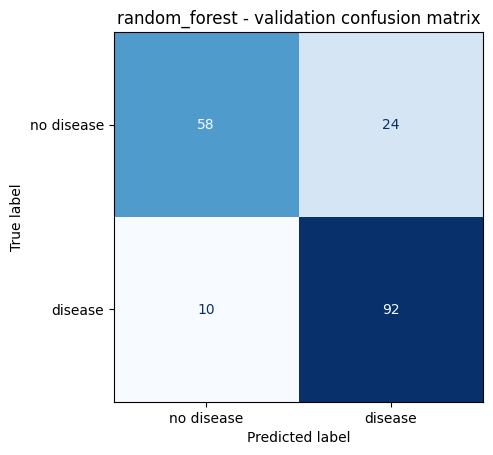

In [5]:
ConfusionMatrixDisplay(
    confusion_matrix(y_val, pred), display_labels=["no disease", "disease"]
).plot(cmap="Blues", colorbar=False)
plt.title(f"{MODEL_NAME} - validation confusion matrix")
plt.show()

## Hyperparameter comparison

`n_estimators` sets how many trees vote, `max_depth` caps each tree, and
`max_features` controls how many candidate features each split may consider
(the source of the forest's decorrelation). The table shows the ten best
cross-validated configurations.

In [6]:
cv_results = pd.DataFrame(search.cv_results_)
param_cols = ["param_model__n_estimators", "param_model__max_depth", "param_model__max_features"]

rf_grid = cv_results[param_cols + ["mean_test_score", "std_test_score"]].copy()
rf_grid = rf_grid.rename(columns={
    "param_model__n_estimators": "n_estimators",
    "param_model__max_depth": "max_depth",
    "param_model__max_features": "max_features",
    "mean_test_score": "cv_roc_auc",
    "std_test_score": "cv_std",
})
rf_grid.sort_values("cv_roc_auc", ascending=False).head(10).round(3)

,n_estimators,max_depth,max_features,cv_roc_auc,cv_std
6,100,5,sqrt,0.867,0.028
9,100,5,log2,0.867,0.028
7,300,5,sqrt,0.867,0.030
10,300,5,log2,0.867,0.030
11,500,5,log2,0.866,0.031
8,500,5,sqrt,0.866,0.031
15,100,10,log2,0.866,0.033
12,100,10,sqrt,0.866,0.033
2,500,None,sqrt,0.865,0.032
5,500,None,log2,0.865,0.032


## How performance varies with forest size and depth

Holding the best `max_features` fixed, plot the cross-validated ROC-AUC across
`n_estimators` for each `max_depth`. Unlike a single tree, adding more trees
does not overfit - the curve typically just flattens once the ensemble
average stabilizes - while `max_depth` controls how flexible each member is
(`None` = unbounded depth).

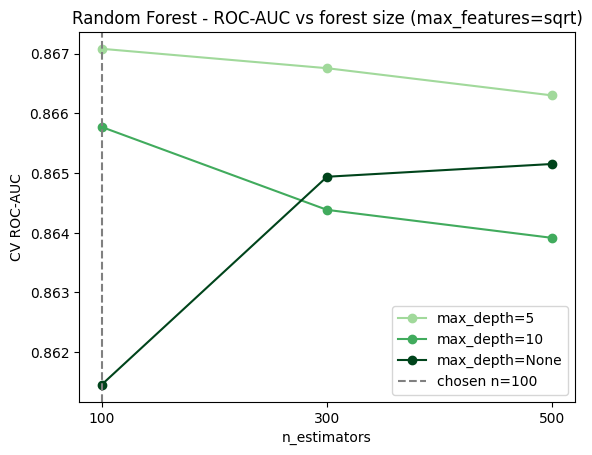

In [7]:
best_mf = search.best_params_["model__max_features"]
n_grid = cfg["grid"]["model__n_estimators"]

# One line per depth cap, light-to-dark as trees get deeper.
depth_colors = dict(zip([5, 10, None], ["#a1d99b", "#41ab5d", "#00441b"]))

for depth, color in depth_colors.items():
    rows = rf_grid[(rf_grid["max_features"] == best_mf) & (rf_grid["max_depth"] == depth)] \
        if depth is not None else \
        rf_grid[(rf_grid["max_features"] == best_mf) & (rf_grid["max_depth"].isna())]
    score_by_n = dict(zip(rows["n_estimators"], rows["cv_roc_auc"]))
    plt.plot(n_grid, [score_by_n[n] for n in n_grid],
             marker="o", color=color, label=f"max_depth={depth}")

plt.axvline(search.best_params_["model__n_estimators"], color="gray", ls="--",
            label=f"chosen n={search.best_params_['model__n_estimators']}")
plt.xticks(n_grid)
plt.xlabel("n_estimators")
plt.ylabel("CV ROC-AUC")
plt.title(f"Random Forest - ROC-AUC vs forest size (max_features={best_mf})")
plt.legend()
plt.show()

## Feature importance

Impurity importances averaged over all trees in the forest - more stable than
a single tree's, but still biased toward continuous features with many split
points, and importance is diluted across correlated features.

Caveat: ~22% of `chol` is iteratively imputed with low-variance synthetic
values (see PROJECT.md), so read its importance with that in mind.

In [8]:
forest = best.named_steps["model"]
importance = pd.Series(forest.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).round(3)

cp_4         0.164
oldpeak      0.130
exang        0.125
age          0.124
thalach      0.120
cp_2         0.086
sex          0.069
chol         0.068
trestbps     0.042
cp_3         0.020
fbs          0.015
restecg_0    0.012
restecg_1    0.011
restecg_2    0.008
cp_1         0.005
dtype: float64

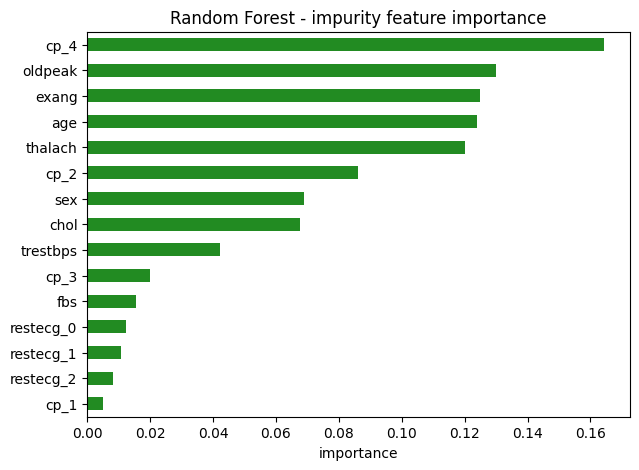

In [9]:
importance.sort_values().plot(kind="barh", color="forestgreen", figsize=(7, 5))
plt.xlabel("importance")
plt.title("Random Forest - impurity feature importance")
plt.show()

## ROC curve (validation)

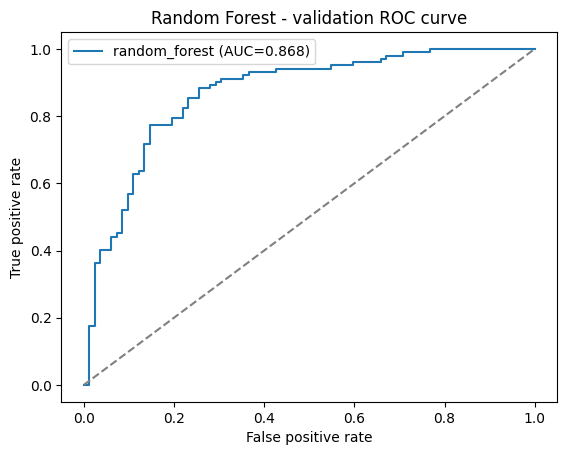

In [10]:
fpr, tpr, _ = roc_curve(y_val, proba)
plt.plot(fpr, tpr, label=f"{MODEL_NAME} (AUC={metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Random Forest - validation ROC curve")
plt.legend()
plt.show()

## Notes

- Test set intentionally not touched - see the comparison notebook for the
  single final test evaluation of the selected model.
- Forest probabilities average leaf class fractions across many trees, so the
  ROC curve is much smoother than a single Decision Tree's.
- This notebook is Random Forest specific. To explore another model, start
  from the shared template and swap in a model-appropriate diagnostic.